In [1]:
from pathlib import Path
import json
from itertools import combinations

import numpy as np
import pandas as pd
from scipy import ndimage
from scipy.optimize import linear_sum_assignment

import matplotlib.pyplot as plt


In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA_ROOT = PROJECT_ROOT / "data/sample"

SAMPLE_ID = "44b6_0113de3b"

PROCESSED_DIR = (
    DATA_ROOT
    / "processed"
    / "stage_6_processed_dataset"
    / SAMPLE_ID
)

CELLS_DIR = PROCESSED_DIR / "cells"
SEGMENTATION_DIR = PROCESSED_DIR / "segmentation"

TRACKS_INPUT_PATH = (
    DATA_ROOT
    / "processed"
    / "stage_7_cell_tracking"
    / "tracks.csv"
)

print("Project root:", PROJECT_ROOT)
print("Tracks input:", TRACKS_INPUT_PATH)
print("Segmentation directory:", SEGMENTATION_DIR)


Project root: D:\Projects\Kaggle\cell-tracking
Tracks input: D:\Projects\Kaggle\cell-tracking\data\sample\processed\stage_7_cell_tracking\tracks.csv
Segmentation directory: D:\Projects\Kaggle\cell-tracking\data\sample\processed\stage_6_processed_dataset\44b6_0113de3b\segmentation


In [3]:
# ------------------------------------------------------------
# Load tracks produced by Stage 7
# ------------------------------------------------------------

tracks = pd.read_csv(TRACKS_INPUT_PATH)

print(f"Loaded {len(tracks):,} track records.")
print(f"Found {tracks['track_id'].nunique():,} tracks.")

tracks.head()


Loaded 4,192 track records.
Found 456 tracks.


,track_id,frame,cell,cell_id,z,y,x,volume,touches_boundary,boundary_faces,...,relative_velocity_x_um_per_frame,relative_velocity_valid,relative_velocity_samples,relative_velocity_error_ema_um,relative_motion_confidence_next_frame,relative_velocity_updated,position_residual_ema_z_um,position_residual_ema_y_um,position_residual_ema_x_um,position_residual_samples
0,0,0,0,1,0.231183,6.354839,52.204301,186.0,True,z_min|y_min,...,0.0,False,0,0.0,0.0,False,0.0,0.0,0.0,0
1,1,0,1,2,0.153153,6.815315,71.774775,222.0,True,z_min|y_min,...,0.0,False,0,0.0,0.0,False,0.0,0.0,0.0,0
2,2,0,2,3,7.066667,36.198876,76.762921,2670.0,True,z_min,...,0.0,False,0,0.0,0.0,False,0.0,0.0,0.0,0
3,3,0,3,4,1.074627,62.743555,58.230665,737.0,True,z_min,...,0.0,False,0,0.0,0.0,False,0.0,0.0,0.0,0
4,4,0,4,5,1.422780,88.038610,90.005792,518.0,True,z_min,...,0.0,False,0,0.0,0.0,False,0.0,0.0,0.0,0


In [4]:
# ------------------------------------------------------------
# Load per-frame detection tables and segmentation-label paths
# ------------------------------------------------------------

cell_files = sorted(CELLS_DIR.glob("t*.csv"))

time_frames = [
    pd.read_csv(file)
    for file in cell_files
]

segmentation_files = sorted(
    SEGMENTATION_DIR.glob("t*.npy")
)

if not cell_files:
    raise FileNotFoundError(
        f"No per-frame cell tables found in:\n{CELLS_DIR}"
    )

if len(segmentation_files) != len(time_frames):
    raise ValueError(
        "The number of segmentation volumes does not match "
        "the number of cell tables: "
        f"{len(segmentation_files)} vs {len(time_frames)}."
    )

print(f"Loaded {len(time_frames)} timepoints.")
print(f"Found {len(segmentation_files)} segmentation volumes.")


Loaded 20 timepoints.
Found 20 segmentation volumes.


## Stage 7A — Legacy gap closing remains disabled

The previous proximity-only stitcher can connect unrelated track fragments before a merge event is interpreted. It is retained only for comparison. Merge-aware repair below operates directly on the original Stage 7 tracks.


In [5]:
# ============================================================
# Stage 7A — Legacy gap closing / track stitching
# ============================================================

ENABLE_LEGACY_GAP_CLOSING = False

MAX_GAP = 2
STITCH_MAX_DISTANCE = 15.0


def stitch_tracks(
    tracks: pd.DataFrame,
    max_gap: int = MAX_GAP,
    max_distance: float = STITCH_MAX_DISTANCE,
) -> pd.DataFrame:
    """Legacy proximity-only fragment stitching."""

    tracks = tracks.copy()
    last_frame = int(tracks["frame"].max())

    ends = (
        tracks.sort_values("frame")
        .groupby("track_id")
        .tail(1)
        .set_index("track_id")
    )
    starts = (
        tracks.sort_values("frame")
        .groupby("track_id")
        .head(1)
        .set_index("track_id")
    )

    candidate_parents = ends[ends["frame"] < last_frame]
    candidate_children = starts[starts["frame"] > 0]

    merges: dict[int, int] = {}

    for parent_id, parent_row in candidate_parents.sort_values("frame").iterrows():
        window = candidate_children[
            (candidate_children["frame"] > parent_row["frame"])
            & (
                candidate_children["frame"]
                <= parent_row["frame"] + max_gap
            )
            & (candidate_children.index != parent_id)
        ]

        if window.empty:
            continue

        distance = np.sqrt(
            (window["z"] - parent_row["z"]) ** 2
            + (window["y"] - parent_row["y"]) ** 2
            + (window["x"] - parent_row["x"]) ** 2
        )

        candidates = distance[distance <= max_distance]

        if candidates.empty:
            continue

        best_child = int(candidates.idxmin())

        if best_child in merges:
            continue

        merges[best_child] = int(parent_id)

    def resolve(track_id: int) -> int:
        seen: set[int] = set()

        while track_id in merges and track_id not in seen:
            seen.add(track_id)
            track_id = merges[track_id]

        return track_id

    tracks["track_id"] = tracks["track_id"].map(resolve)

    print(
        f"Legacy stitcher joined {len(merges)} fragment(s) "
        f"with a gap of at most {max_gap} frame(s)."
    )

    return tracks


tracks_before_stitching = tracks.copy()

if ENABLE_LEGACY_GAP_CLOSING:
    tracks = stitch_tracks(tracks)
else:
    print("Legacy proximity-only track stitching is disabled.")
    print("Merge-aware repair will use the original Stage 7 IDs.")


Legacy proximity-only track stitching is disabled.
Merge-aware repair will use the original Stage 7 IDs.


## Stage 7B — Temporal merge detection and direct track repair

### Implementation plan

1. **Detect a strong merge onset.** Two established tracks must both end at frame `t`, and a new track must start at frame `t + 1`.
2. **Validate the two-to-one hypothesis.** The new detection is tested against both parent trajectories using physical distance, volume conservation, integrated-intensity conservation, the volume-weighted parent centroid, and bounding-box containment.
3. **Trace the merged observation.** The merged component is followed across later frames even if its temporary track ID changes.
4. **Recover the two hidden centers.** The pre-merge parent axis and parent-volume ratio are preserved. For each merged frame, contraction factors are searched and scored using the 3D distance transform of the merged instance mask.
5. **Detect re-separation when possible.** A continuing merged track plus a new track, or two new tracks, is accepted as a split only when their combined volume and positions explain the two parents.
6. **Rewrite `tracks.csv`.** Every observed merged detection is replaced by two virtual track rows carrying the two recovered centers and the original parent IDs. When a reliable split is found, the two outgoing tracks are remapped to the corresponding parent identities.

No individual split masks are created. The original merged `cell` and `cell_id` are retained in both virtual rows so the source observation remains traceable.


In [6]:
# ============================================================
# Stage 7B configuration
# ============================================================

VOXEL_SIZE_ZYX = np.asarray(
    [1.625, 0.40625, 0.40625],
    dtype=float,
)

# Strong onset: both parents end at t and a new merged track starts at t + 1.
MERGE_ONSET_FRAME_GAP = 1
MERGE_MIN_PARENT_TRACK_LENGTH = 2
MERGE_EXCLUDE_BOUNDARY = True

MERGE_SEARCH_RADIUS_UM = 12.0
MERGE_PARENT_PAIR_MAX_SEPARATION_UM = 25.0
MERGE_MAX_VOLUME_REL_ERROR = 0.25
MERGE_MAX_INTENSITY_SUM_REL_ERROR = 0.60
MERGE_MAX_WEIGHTED_CENTROID_ERROR_UM = 6.0
MERGE_MIN_ONSET_SCORE = 0.72

MERGE_PARENT_HISTORY_LENGTH = 3
MERGE_BBOX_MARGIN_ZYX = np.asarray(
    [1.0, 3.0, 3.0],
    dtype=float,
)

# Hidden-center reconstruction.
CENTER_ALPHA_MIN = 0.25
CENTER_ALPHA_MAX = 1.10
CENTER_ALPHA_STEPS = 86
CENTER_MIN_DEPTH_UM = 0.25
CENTER_SEPARATION_WEIGHT = 0.15
CENTER_MASK_MARGIN_ZYX = np.asarray(
    [2, 4, 4],
    dtype=int,
)

# Following one merged observation through track-ID breaks.
MERGE_MAX_DURATION_FRAMES = 10
MERGED_CONTINUATION_MAX_DISTANCE_UM = 10.0
MERGED_CONTINUATION_MAX_VOLUME_REL_ERROR = 0.35
MERGED_CONTINUATION_MIN_SCORE = 0.55

# Re-separation detection.
SPLIT_SEARCH_RADIUS_UM = 12.0
SPLIT_MAX_COMBINED_VOLUME_REL_ERROR = 0.35
SPLIT_MAX_PARENT_VOLUME_REL_ERROR = 0.60
SPLIT_MIN_SCORE = 0.65


OPTIONAL_DETECTION_FEATURES = [
    "cell_id",
    "intensity_sum",
    "intensity_mean",
    "intensity_std",
    "equivalent_radius",
    "axis_major",
    "axis_middle",
    "axis_minor",
    "elongation",
    "flatness",
    "anisotropy",
    "solidity",
    "compactness",
    "bbox_depth",
    "bbox_height",
    "bbox_width",
    "z_min",
    "y_min",
    "x_min",
    "z_max",
    "y_max",
    "x_max",
    "touches_boundary",
    "boundary_faces",
]


def enrich_tracks_with_detection_features(
    tracks: pd.DataFrame,
    time_frames: list[pd.DataFrame],
) -> pd.DataFrame:
    """Attach Stage 6 detection features to each track observation."""

    enriched = tracks.copy()

    values: dict[str, list[object]] = {
        column: []
        for column in OPTIONAL_DETECTION_FEATURES
    }

    for track_row in enriched.itertuples(index=False):
        frame = int(track_row.frame)
        cell_index = int(track_row.cell)

        if not 0 <= frame < len(time_frames):
            raise IndexError(
                f"Track frame {frame} is outside the loaded sequence."
            )

        detections = time_frames[frame]

        if not 0 <= cell_index < len(detections):
            raise IndexError(
                f"Cell index {cell_index} is invalid for frame {frame}."
            )

        detection = detections.iloc[cell_index]

        for column in OPTIONAL_DETECTION_FEATURES:
            values[column].append(
                detection[column]
                if column in detection.index
                else np.nan
            )

    for column, column_values in values.items():
        enriched[column] = column_values

    if "cell_id" not in enriched or enriched["cell_id"].isna().all():
        enriched["cell_id"] = enriched["cell"].astype(int) + 1

    return enriched


track_features = enrich_tracks_with_detection_features(
    tracks,
    time_frames,
)

track_start_frames = (
    track_features.groupby("track_id")["frame"]
    .min()
    .astype(int)
    .to_dict()
)

track_end_frames = (
    track_features.groupby("track_id")["frame"]
    .max()
    .astype(int)
    .to_dict()
)

track_lengths = (
    track_features.groupby("track_id")
    .size()
    .astype(int)
    .to_dict()
)

frame_features = {
    int(frame): group.copy()
    for frame, group in track_features.groupby("frame")
}

print(
    f"Prepared {len(track_features):,} observations "
    "with detection-level features."
)


Prepared 4,192 observations with detection-level features.


In [7]:
# ------------------------------------------------------------
# General temporal and geometric helpers
# ------------------------------------------------------------

def physical_distance(
    point_a_zyx: np.ndarray,
    point_b_zyx: np.ndarray,
) -> float:
    delta = (
        np.asarray(point_a_zyx, dtype=float)
        - np.asarray(point_b_zyx, dtype=float)
    )

    return float(
        np.linalg.norm(delta * VOXEL_SIZE_ZYX)
    )


def relative_error(
    actual: float,
    expected: float,
) -> float:
    if (
        not np.isfinite(actual)
        or not np.isfinite(expected)
        or expected <= 0
    ):
        return np.nan

    return float(
        abs(actual - expected) / expected
    )


def exponential_score(
    error: float,
    scale: float,
) -> float:
    if not np.isfinite(error):
        return np.nan

    return float(
        np.exp(-error / max(scale, 1e-12))
    )


def weighted_score(
    components: dict[str, float],
    weights: dict[str, float],
) -> float:
    numerator = 0.0
    denominator = 0.0

    for name, value in components.items():
        if np.isfinite(value):
            weight = float(weights[name])
            numerator += weight * float(value)
            denominator += weight

    return (
        float(numerator / denominator)
        if denominator > 0
        else 0.0
    )


def as_bool(value: object) -> bool:
    if value is None or (
        isinstance(value, float)
        and np.isnan(value)
    ):
        return False

    if isinstance(value, str):
        return value.strip().lower() in {
            "true",
            "1",
            "yes",
            "y",
        }

    return bool(value)


def predict_track_position(
    track_table: pd.DataFrame,
    track_id: int,
    source_frame: int,
    target_frame: int,
) -> np.ndarray:
    """Constant-velocity prediction from the last two observations."""

    history = (
        track_table[
            (track_table["track_id"] == int(track_id))
            & (track_table["frame"] <= int(source_frame))
        ]
        .sort_values("frame")
    )

    if history.empty:
        raise KeyError(
            f"No history found for track {track_id} "
            f"up to frame {source_frame}."
        )

    last = history.iloc[-1]
    last_position = last[
        ["z", "y", "x"]
    ].to_numpy(dtype=float)

    velocity = np.zeros(3, dtype=float)

    if len(history) >= 2:
        previous = history.iloc[-2]
        frame_delta = float(
            last["frame"] - previous["frame"]
        )

        if frame_delta > 0:
            previous_position = previous[
                ["z", "y", "x"]
            ].to_numpy(dtype=float)

            velocity = (
                last_position - previous_position
            ) / frame_delta

    prediction_horizon = float(
        target_frame - last["frame"]
    )

    return (
        last_position
        + velocity * prediction_horizon
    )


def recent_track_reference(
    track_id: int,
    source_frame: int,
    column: str,
    history_length: int = MERGE_PARENT_HISTORY_LENGTH,
) -> float:
    history = (
        track_features[
            (track_features["track_id"] == int(track_id))
            & (track_features["frame"] <= int(source_frame))
        ]
        .sort_values("frame")
        .tail(history_length)
    )

    if column not in history:
        return np.nan

    values = pd.to_numeric(
        history[column],
        errors="coerce",
    )

    values = values[np.isfinite(values)]

    return (
        float(values.median())
        if len(values)
        else np.nan
    )


def point_inside_expanded_bbox(
    point_zyx: np.ndarray,
    detection: pd.Series,
    margin_zyx: np.ndarray = MERGE_BBOX_MARGIN_ZYX,
) -> bool | None:
    required = [
        "z_min", "y_min", "x_min",
        "z_max", "y_max", "x_max",
    ]

    if any(
        column not in detection.index
        or not np.isfinite(detection[column])
        for column in required
    ):
        return None

    start = detection[
        ["z_min", "y_min", "x_min"]
    ].to_numpy(dtype=float) - margin_zyx

    stop = detection[
        ["z_max", "y_max", "x_max"]
    ].to_numpy(dtype=float) + margin_zyx

    point = np.asarray(
        point_zyx,
        dtype=float,
    )

    return bool(
        np.all(point >= start)
        and np.all(point <= stop)
    )


In [8]:
# ------------------------------------------------------------
# Strong two-ended-tracks -> one-new-track onset detector
# ------------------------------------------------------------

def score_merge_onset(
    parent_a: pd.Series,
    parent_b: pd.Series,
    merged: pd.Series,
) -> dict[str, float] | None:
    parent_frame = int(parent_a["frame"])
    merged_frame = int(merged["frame"])

    track_a = int(parent_a["track_id"])
    track_b = int(parent_b["track_id"])

    predicted_a = predict_track_position(
        track_features,
        track_id=track_a,
        source_frame=parent_frame,
        target_frame=merged_frame,
    )
    predicted_b = predict_track_position(
        track_features,
        track_id=track_b,
        source_frame=parent_frame,
        target_frame=merged_frame,
    )

    merged_position = merged[
        ["z", "y", "x"]
    ].to_numpy(dtype=float)

    distance_a_um = physical_distance(
        predicted_a,
        merged_position,
    )
    distance_b_um = physical_distance(
        predicted_b,
        merged_position,
    )

    if max(
        distance_a_um,
        distance_b_um,
    ) > MERGE_SEARCH_RADIUS_UM:
        return None

    parent_separation_um = physical_distance(
        predicted_a,
        predicted_b,
    )

    if (
        parent_separation_um
        > MERGE_PARENT_PAIR_MAX_SEPARATION_UM
    ):
        return None

    volume_a = recent_track_reference(
        track_a,
        parent_frame,
        "volume",
    )
    volume_b = recent_track_reference(
        track_b,
        parent_frame,
        "volume",
    )

    merged_volume = float(
        merged["volume"]
    )
    expected_volume = volume_a + volume_b

    volume_error = relative_error(
        merged_volume,
        expected_volume,
    )

    if (
        not np.isfinite(volume_error)
        or volume_error
        > MERGE_MAX_VOLUME_REL_ERROR
    ):
        return None

    expected_centroid = (
        volume_a * predicted_a
        + volume_b * predicted_b
    ) / expected_volume

    centroid_error_um = physical_distance(
        merged_position,
        expected_centroid,
    )

    if (
        centroid_error_um
        > MERGE_MAX_WEIGHTED_CENTROID_ERROR_UM
    ):
        return None

    intensity_a = recent_track_reference(
        track_a,
        parent_frame,
        "intensity_sum",
    )
    intensity_b = recent_track_reference(
        track_b,
        parent_frame,
        "intensity_sum",
    )
    merged_intensity = float(
        merged.get("intensity_sum", np.nan)
    )

    intensity_error = relative_error(
        merged_intensity,
        intensity_a + intensity_b,
    )

    if (
        np.isfinite(intensity_error)
        and intensity_error
        > MERGE_MAX_INTENSITY_SUM_REL_ERROR
    ):
        return None

    bbox_a = point_inside_expanded_bbox(
        predicted_a,
        merged,
    )
    bbox_b = point_inside_expanded_bbox(
        predicted_b,
        merged,
    )

    bbox_values = [
        float(value)
        for value in [bbox_a, bbox_b]
        if value is not None
    ]

    bbox_score = (
        float(np.mean(bbox_values))
        if bbox_values
        else np.nan
    )

    components = {
        "parent_distance": exponential_score(
            0.5 * (
                distance_a_um + distance_b_um
            ),
            6.0,
        ),
        "centroid": exponential_score(
            centroid_error_um,
            3.0,
        ),
        "volume": exponential_score(
            volume_error,
            0.15,
        ),
        "intensity": exponential_score(
            intensity_error,
            0.30,
        ),
        "bbox": bbox_score,
    }

    weights = {
        "parent_distance": 0.25,
        "centroid": 0.25,
        "volume": 0.35,
        "intensity": 0.10,
        "bbox": 0.05,
    }

    score = weighted_score(
        components,
        weights,
    )

    return {
        "score": score,
        "predicted_a_z": float(predicted_a[0]),
        "predicted_a_y": float(predicted_a[1]),
        "predicted_a_x": float(predicted_a[2]),
        "predicted_b_z": float(predicted_b[0]),
        "predicted_b_y": float(predicted_b[1]),
        "predicted_b_x": float(predicted_b[2]),
        "distance_a_um": distance_a_um,
        "distance_b_um": distance_b_um,
        "parent_separation_um": parent_separation_um,
        "centroid_error_um": centroid_error_um,
        "volume_a": volume_a,
        "volume_b": volume_b,
        "merged_volume": merged_volume,
        "volume_error": volume_error,
        "intensity_sum_a": intensity_a,
        "intensity_sum_b": intensity_b,
        "merged_intensity_sum": merged_intensity,
        "intensity_sum_error": intensity_error,
        "bbox_score": bbox_score,
    }


track_ends = (
    track_features.sort_values("frame")
    .groupby("track_id")
    .tail(1)
)

track_starts = (
    track_features.sort_values("frame")
    .groupby("track_id")
    .head(1)
)

candidate_records: list[dict[str, object]] = []

for _, merged in track_starts.iterrows():
    merged_frame = int(merged["frame"])

    if merged_frame <= 0:
        continue

    parent_frame = (
        merged_frame - MERGE_ONSET_FRAME_GAP
    )

    ended = track_ends[
        track_ends["frame"].astype(int)
        == parent_frame
    ].copy()

    if ended.empty:
        continue

    long_enough = ended["track_id"].map(
        lambda track_id: (
            track_lengths.get(
                int(track_id),
                0,
            )
            >= MERGE_MIN_PARENT_TRACK_LENGTH
        )
    ).astype(bool)

    ended = ended.loc[
        long_enough
    ].copy()

    if ended.empty:
        continue

    if MERGE_EXCLUDE_BOUNDARY:
        if as_bool(
            merged.get(
                "touches_boundary",
                False,
            )
        ):
            continue

        boundary_mask = (
            ended["touches_boundary"]
            .map(as_bool)
            .astype(bool)
        )

        ended = ended.loc[
            ~boundary_mask
        ].copy()

    if len(ended) < 2:
        continue

    merged_position = merged[
        ["z", "y", "x"]
    ].to_numpy(dtype=float)

    nearby_indices: list[int] = []

    for parent_index, parent in ended.iterrows():
        predicted = predict_track_position(
            track_features,
            track_id=int(parent["track_id"]),
            source_frame=parent_frame,
            target_frame=merged_frame,
        )

        if (
            physical_distance(
                predicted,
                merged_position,
            )
            <= MERGE_SEARCH_RADIUS_UM
        ):
            nearby_indices.append(parent_index)

    for index_a, index_b in combinations(
        nearby_indices,
        2,
    ):
        parent_a = ended.loc[index_a]
        parent_b = ended.loc[index_b]

        result = score_merge_onset(
            parent_a,
            parent_b,
            merged,
        )

        if result is None:
            continue

        if result["score"] < MERGE_MIN_ONSET_SCORE:
            continue

        candidate_records.append({
            "status": "onset_candidate",
            "frame": parent_frame,
            "merged_frame": merged_frame,
            "track_a": int(parent_a["track_id"]),
            "track_b": int(parent_b["track_id"]),
            "merged_track": int(merged["track_id"]),
            "cell_a": int(parent_a["cell"]),
            "cell_b": int(parent_b["cell"]),
            "merged_cell": int(merged["cell"]),
            "cell_id_a": int(parent_a["cell_id"]),
            "cell_id_b": int(parent_b["cell_id"]),
            "merged_cell_id": int(merged["cell_id"]),
            **result,
        })


merge_onset_candidates = pd.DataFrame(
    candidate_records
)

accepted_onsets: list[dict[str, object]] = []
claimed_parent_tracks: set[int] = set()
claimed_merged_tracks: set[int] = set()

if not merge_onset_candidates.empty:
    for _, candidate in merge_onset_candidates.sort_values(
        "score",
        ascending=False,
    ).iterrows():
        parent_tracks = {
            int(candidate["track_a"]),
            int(candidate["track_b"]),
        }

        merged_track = int(
            candidate["merged_track"]
        )

        if (
            parent_tracks & claimed_parent_tracks
            or merged_track in claimed_merged_tracks
        ):
            continue

        accepted_onsets.append(
            candidate.to_dict()
        )

        claimed_parent_tracks |= parent_tracks
        claimed_merged_tracks.add(merged_track)

merge_onsets = pd.DataFrame(
    accepted_onsets
)

if not merge_onsets.empty:
    merge_onsets = (
        merge_onsets.sort_values(
            ["merged_frame", "score"],
            ascending=[True, False],
        )
        .reset_index(drop=True)
    )

print(
    f"Found {len(merge_onset_candidates)} strong onset candidate(s)."
)
print(
    f"Retained {len(merge_onsets)} non-conflicting onset(s)."
)

if not merge_onsets.empty:
    merge_onsets[
        [
            "frame",
            "merged_frame",
            "track_a",
            "track_b",
            "merged_track",
            "merged_cell_id",
            "score",
            "volume_error",
            "centroid_error_um",
        ]
    ].head(20)


Found 0 strong onset candidate(s).
Retained 0 non-conflicting onset(s).


## Stage 7B.1 — Reconstruct two centers through the merged interval

The parent axis is measured once immediately before the merge. At every merged frame, the axis is recentered on the observed merged centroid. Parent volumes determine the asymmetric position of the two centers. A contraction factor is selected by requiring both candidate points to lie deeply inside the merged instance mask while retaining useful separation.


In [9]:
# ------------------------------------------------------------
# Segmentation-mask access and hidden-center reconstruction
# ------------------------------------------------------------

segmentation_cache: dict[int, np.ndarray] = {}


def load_segmentation_frame(
    frame: int,
) -> np.ndarray:
    frame = int(frame)

    if frame not in segmentation_cache:
        segmentation_cache[frame] = np.load(
            segmentation_files[frame],
            mmap_mode="r",
            allow_pickle=False,
        )

    return segmentation_cache[frame]


def detection_mask_crop(
    frame: int,
    detection: pd.Series,
) -> tuple[np.ndarray, np.ndarray]:
    labels = load_segmentation_frame(frame)

    shape = np.asarray(
        labels.shape,
        dtype=int,
    )

    bbox_columns = [
        "z_min", "y_min", "x_min",
        "z_max", "y_max", "x_max",
    ]

    if all(
        column in detection.index
        and np.isfinite(detection[column])
        for column in bbox_columns
    ):
        start = np.floor(
            detection[
                ["z_min", "y_min", "x_min"]
            ].to_numpy(dtype=float)
        ).astype(int)

        stop = (
            np.ceil(
                detection[
                    ["z_max", "y_max", "x_max"]
                ].to_numpy(dtype=float)
            ).astype(int)
            + 1
        )
    else:
        center = np.rint(
            detection[
                ["z", "y", "x"]
            ].to_numpy(dtype=float)
        ).astype(int)

        fallback_radius = np.asarray(
            [8, 20, 20],
            dtype=int,
        )

        start = center - fallback_radius
        stop = center + fallback_radius + 1

    start = np.maximum(
        start - CENTER_MASK_MARGIN_ZYX,
        0,
    )
    stop = np.minimum(
        stop + CENTER_MASK_MARGIN_ZYX,
        shape,
    )

    slices = tuple(
        slice(int(a), int(b))
        for a, b in zip(start, stop)
    )

    crop = np.asarray(
        labels[slices]
    )

    target_label = int(
        detection["cell_id"]
    )

    mask = crop == target_label

    if not mask.any():
        center = np.rint(
            detection[
                ["z", "y", "x"]
            ].to_numpy(dtype=float)
        ).astype(int)

        center = np.clip(
            center,
            0,
            shape - 1,
        )

        fallback_label = int(
            labels[tuple(center)]
        )

        if fallback_label > 0:
            mask = crop == fallback_label

    if not mask.any():
        raise ValueError(
            "Could not recover the merged instance mask for "
            f"frame={frame}, cell_id={target_label}."
        )

    return mask, start.astype(float)


def sample_volume_at_point(
    volume: np.ndarray,
    point_zyx: np.ndarray,
) -> float:
    coordinates = np.asarray(
        point_zyx,
        dtype=float,
    ).reshape(3, 1)

    return float(
        ndimage.map_coordinates(
            volume.astype(float),
            coordinates,
            order=1,
            mode="constant",
            cval=0.0,
        )[0]
    )


def reconstruct_hidden_centers(
    merged_detection: pd.Series,
    parent_axis_physical_zyx: np.ndarray,
    volume_a: float,
    volume_b: float,
) -> dict[str, object]:
    frame = int(
        merged_detection["frame"]
    )

    merged_centroid_voxel = merged_detection[
        ["z", "y", "x"]
    ].to_numpy(dtype=float)

    merged_centroid_physical = (
        merged_centroid_voxel
        * VOXEL_SIZE_ZYX
    )

    parent_axis_physical = np.asarray(
        parent_axis_physical_zyx,
        dtype=float,
    )

    if (
        parent_axis_physical.shape != (3,)
        or np.linalg.norm(parent_axis_physical) <= 0
    ):
        raise ValueError(
            "The pre-merge parent axis is invalid."
        )

    total_volume = float(
        volume_a + volume_b
    )

    weight_a = float(
        volume_a / total_volume
    )
    weight_b = float(
        volume_b / total_volume
    )

    mask_crop, crop_start = detection_mask_crop(
        frame,
        merged_detection,
    )

    distance_crop = ndimage.distance_transform_edt(
        mask_crop,
        sampling=VOXEL_SIZE_ZYX,
    )

    best: dict[str, object] | None = None

    for alpha in np.linspace(
        CENTER_ALPHA_MIN,
        CENTER_ALPHA_MAX,
        CENTER_ALPHA_STEPS,
    ):
        center_a_physical = (
            merged_centroid_physical
            - weight_b
            * alpha
            * parent_axis_physical
        )

        center_b_physical = (
            merged_centroid_physical
            + weight_a
            * alpha
            * parent_axis_physical
        )

        center_a_voxel = (
            center_a_physical
            / VOXEL_SIZE_ZYX
        )
        center_b_voxel = (
            center_b_physical
            / VOXEL_SIZE_ZYX
        )

        local_a = center_a_voxel - crop_start
        local_b = center_b_voxel - crop_start

        depth_a_um = sample_volume_at_point(
            distance_crop,
            local_a,
        )
        depth_b_um = sample_volume_at_point(
            distance_crop,
            local_b,
        )

        minimum_depth_um = min(
            depth_a_um,
            depth_b_um,
        )

        separation_um = float(
            np.linalg.norm(
                center_b_physical
                - center_a_physical
            )
        )

        center_score = (
            2.0 * minimum_depth_um
            + depth_a_um
            + depth_b_um
            + CENTER_SEPARATION_WEIGHT
            * separation_um
        )

        candidate = {
            "center_a_zyx": center_a_voxel,
            "center_b_zyx": center_b_voxel,
            "alpha": float(alpha),
            "depth_a_um": float(depth_a_um),
            "depth_b_um": float(depth_b_um),
            "minimum_depth_um": float(
                minimum_depth_um
            ),
            "separation_um": separation_um,
            "center_score": float(center_score),
        }

        if (
            best is None
            or candidate["center_score"]
            > best["center_score"]
        ):
            best = candidate

    if best is None:
        raise RuntimeError(
            "No temporal center candidate was generated."
        )

    if (
        float(best["minimum_depth_um"])
        < CENTER_MIN_DEPTH_UM
    ):
        raise ValueError(
            "At least one reconstructed center lies too "
            "close to the merged-cell boundary."
        )

    return best


In [10]:
# ------------------------------------------------------------
# Follow the merged component and detect reliable re-separation
# ------------------------------------------------------------

def predict_merged_position(
    observations: list[dict[str, object]],
    target_frame: int,
) -> np.ndarray:
    last = observations[-1]
    last_position = np.asarray(
        last["merged_position_zyx"],
        dtype=float,
    )

    if len(observations) < 2:
        return last_position

    previous = observations[-2]

    frame_delta = float(
        int(last["frame"])
        - int(previous["frame"])
    )

    if frame_delta <= 0:
        return last_position

    velocity = (
        last_position
        - np.asarray(
            previous["merged_position_zyx"],
            dtype=float,
        )
    ) / frame_delta

    horizon = float(
        target_frame - int(last["frame"])
    )

    return last_position + velocity * horizon


def continuation_score(
    candidate: pd.Series,
    predicted_position_zyx: np.ndarray,
    expected_volume: float,
    previous_track_id: int,
) -> float | None:
    distance_um = physical_distance(
        candidate[
            ["z", "y", "x"]
        ].to_numpy(dtype=float),
        predicted_position_zyx,
    )

    if (
        distance_um
        > MERGED_CONTINUATION_MAX_DISTANCE_UM
    ):
        return None

    volume_error = relative_error(
        float(candidate["volume"]),
        expected_volume,
    )

    if (
        not np.isfinite(volume_error)
        or volume_error
        > MERGED_CONTINUATION_MAX_VOLUME_REL_ERROR
    ):
        return None

    score = (
        0.60 * exponential_score(
            distance_um,
            5.0,
        )
        + 0.35 * exponential_score(
            volume_error,
            0.20,
        )
        + 0.05 * float(
            int(candidate["track_id"])
            == int(previous_track_id)
        )
    )

    return float(score)


def best_split_pair(
    candidates: pd.DataFrame,
    frame: int,
    previous_track_id: int,
    predicted_merged_position_zyx: np.ndarray,
    previous_center_a_zyx: np.ndarray,
    previous_center_b_zyx: np.ndarray,
    previous_merged_position_zyx: np.ndarray,
    volume_a: float,
    volume_b: float,
) -> dict[str, object] | None:
    eligible = candidates.copy()

    eligible = eligible[
        eligible["track_id"].map(
            lambda track_id: (
                int(track_id)
                == int(previous_track_id)
                or track_start_frames.get(
                    int(track_id),
                    -1,
                )
                == int(frame)
            )
        )
    ]

    if len(eligible) < 2:
        return None

    total_parent_volume = float(
        volume_a + volume_b
    )

    merged_shift = (
        np.asarray(
            predicted_merged_position_zyx,
            dtype=float,
        )
        - np.asarray(
            previous_merged_position_zyx,
            dtype=float,
        )
    )

    predicted_a = (
        np.asarray(
            previous_center_a_zyx,
            dtype=float,
        )
        + merged_shift
    )
    predicted_b = (
        np.asarray(
            previous_center_b_zyx,
            dtype=float,
        )
        + merged_shift
    )

    best: dict[str, object] | None = None

    for index_1, index_2 in combinations(
        eligible.index,
        2,
    ):
        child_1 = eligible.loc[index_1]
        child_2 = eligible.loc[index_2]

        child_tracks = {
            int(child_1["track_id"]),
            int(child_2["track_id"]),
        }

        # A split transition must introduce at least one new track.
        if not any(
            track_start_frames.get(
                track_id,
                -1,
            )
            == int(frame)
            for track_id in child_tracks
        ):
            continue

        combined_volume = float(
            child_1["volume"]
            + child_2["volume"]
        )

        combined_volume_error = relative_error(
            combined_volume,
            total_parent_volume,
        )

        if (
            not np.isfinite(
                combined_volume_error
            )
            or combined_volume_error
            > SPLIT_MAX_COMBINED_VOLUME_REL_ERROR
        ):
            continue

        positions = np.stack(
            [
                child_1[
                    ["z", "y", "x"]
                ].to_numpy(dtype=float),
                child_2[
                    ["z", "y", "x"]
                ].to_numpy(dtype=float),
            ],
            axis=0,
        )

        volumes = np.asarray(
            [
                float(child_1["volume"]),
                float(child_2["volume"]),
            ],
            dtype=float,
        )

        expected_positions = np.stack(
            [predicted_a, predicted_b],
            axis=0,
        )

        expected_volumes = np.asarray(
            [volume_a, volume_b],
            dtype=float,
        )

        cost = np.zeros(
            (2, 2),
            dtype=float,
        )

        distance_matrix = np.zeros(
            (2, 2),
            dtype=float,
        )
        volume_error_matrix = np.zeros(
            (2, 2),
            dtype=float,
        )

        for child_index in range(2):
            for parent_index in range(2):
                distance_um = physical_distance(
                    positions[child_index],
                    expected_positions[parent_index],
                )

                parent_volume_error = relative_error(
                    volumes[child_index],
                    expected_volumes[parent_index],
                )

                distance_matrix[
                    child_index,
                    parent_index,
                ] = distance_um

                volume_error_matrix[
                    child_index,
                    parent_index,
                ] = parent_volume_error

                cost[
                    child_index,
                    parent_index,
                ] = (
                    distance_um / 6.0
                    + parent_volume_error / 0.35
                )

        row_indices, column_indices = (
            linear_sum_assignment(cost)
        )

        assigned_parent_for_child = {
            int(child_index): int(parent_index)
            for child_index, parent_index
            in zip(row_indices, column_indices)
        }

        assigned_distances = np.asarray(
            [
                distance_matrix[
                    child_index,
                    assigned_parent_for_child[
                        child_index
                    ],
                ]
                for child_index in range(2)
            ]
        )

        assigned_volume_errors = np.asarray(
            [
                volume_error_matrix[
                    child_index,
                    assigned_parent_for_child[
                        child_index
                    ],
                ]
                for child_index in range(2)
            ]
        )

        if (
            assigned_volume_errors.max()
            > SPLIT_MAX_PARENT_VOLUME_REL_ERROR
        ):
            continue

        weighted_child_centroid = (
            volumes[0] * positions[0]
            + volumes[1] * positions[1]
        ) / max(
            float(volumes.sum()),
            1e-12,
        )

        centroid_error_um = physical_distance(
            weighted_child_centroid,
            predicted_merged_position_zyx,
        )

        pair_score = (
            0.35 * exponential_score(
                combined_volume_error,
                0.20,
            )
            + 0.30 * exponential_score(
                float(
                    assigned_distances.mean()
                ),
                5.0,
            )
            + 0.20 * exponential_score(
                centroid_error_um,
                4.0,
            )
            + 0.15 * exponential_score(
                float(
                    assigned_volume_errors.mean()
                ),
                0.35,
            )
        )

        if pair_score < SPLIT_MIN_SCORE:
            continue

        children = [child_1, child_2]

        parent_a_child_index = next(
            child_index
            for child_index, parent_index
            in assigned_parent_for_child.items()
            if parent_index == 0
        )
        parent_b_child_index = next(
            child_index
            for child_index, parent_index
            in assigned_parent_for_child.items()
            if parent_index == 1
        )

        candidate = {
            "frame": int(frame),
            "score": float(pair_score),
            "combined_volume_error": float(
                combined_volume_error
            ),
            "centroid_error_um": float(
                centroid_error_um
            ),
            "child_track_a": int(
                children[
                    parent_a_child_index
                ]["track_id"]
            ),
            "child_track_b": int(
                children[
                    parent_b_child_index
                ]["track_id"]
            ),
            "child_cell_a": int(
                children[
                    parent_a_child_index
                ]["cell"]
            ),
            "child_cell_b": int(
                children[
                    parent_b_child_index
                ]["cell"]
            ),
            "child_cell_id_a": int(
                children[
                    parent_a_child_index
                ]["cell_id"]
            ),
            "child_cell_id_b": int(
                children[
                    parent_b_child_index
                ]["cell_id"]
            ),
            "distance_a_um": float(
                assigned_distances[
                    parent_a_child_index
                ]
            ),
            "distance_b_um": float(
                assigned_distances[
                    parent_b_child_index
                ]
            ),
            "volume_error_a": float(
                assigned_volume_errors[
                    parent_a_child_index
                ]
            ),
            "volume_error_b": float(
                assigned_volume_errors[
                    parent_b_child_index
                ]
            ),
        }

        if (
            best is None
            or candidate["score"] > best["score"]
        ):
            best = candidate

    return best


def trace_merged_event(
    event: pd.Series,
) -> dict[str, object]:
    merged_frame = int(
        event["merged_frame"]
    )
    merged_track = int(
        event["merged_track"]
    )
    merged_cell = int(
        event["merged_cell"]
    )

    onset_rows = frame_features[
        merged_frame
    ]

    onset_matches = onset_rows[
        (onset_rows["track_id"].astype(int) == merged_track)
        & (onset_rows["cell"].astype(int) == merged_cell)
    ]

    if len(onset_matches) != 1:
        raise ValueError(
            "Could not uniquely recover the merged-onset observation."
        )

    onset_detection = onset_matches.iloc[0]

    predicted_a = event[
        [
            "predicted_a_z",
            "predicted_a_y",
            "predicted_a_x",
        ]
    ].to_numpy(dtype=float)

    predicted_b = event[
        [
            "predicted_b_z",
            "predicted_b_y",
            "predicted_b_x",
        ]
    ].to_numpy(dtype=float)

    parent_axis_physical = (
        predicted_b - predicted_a
    ) * VOXEL_SIZE_ZYX

    volume_a = float(
        event["volume_a"]
    )
    volume_b = float(
        event["volume_b"]
    )
    expected_merged_volume = (
        volume_a + volume_b
    )

    first_centers = reconstruct_hidden_centers(
        onset_detection,
        parent_axis_physical,
        volume_a,
        volume_b,
    )

    observations: list[dict[str, object]] = [{
        "frame": merged_frame,
        "track_id": merged_track,
        "cell": int(onset_detection["cell"]),
        "cell_id": int(onset_detection["cell_id"]),
        "merged_position_zyx": onset_detection[
            ["z", "y", "x"]
        ].to_numpy(dtype=float),
        "merged_volume": float(
            onset_detection["volume"]
        ),
        **first_centers,
    }]

    split: dict[str, object] | None = None
    final_frame = int(
        track_features["frame"].max()
    )

    for next_frame in range(
        merged_frame + 1,
        min(
            final_frame,
            merged_frame
            + MERGE_MAX_DURATION_FRAMES,
        ) + 1,
    ):
        predicted_merged_position = (
            predict_merged_position(
                observations,
                next_frame,
            )
        )

        candidates = frame_features[
            next_frame
        ].copy()

        candidate_distances = candidates.apply(
            lambda row: physical_distance(
                row[
                    ["z", "y", "x"]
                ].to_numpy(dtype=float),
                predicted_merged_position,
            ),
            axis=1,
        )

        nearby = candidates[
            candidate_distances
            <= SPLIT_SEARCH_RADIUS_UM
        ].copy()

        previous = observations[-1]

        split = best_split_pair(
            nearby,
            frame=next_frame,
            previous_track_id=int(
                previous["track_id"]
            ),
            predicted_merged_position_zyx=(
                predicted_merged_position
            ),
            previous_center_a_zyx=np.asarray(
                previous["center_a_zyx"],
                dtype=float,
            ),
            previous_center_b_zyx=np.asarray(
                previous["center_b_zyx"],
                dtype=float,
            ),
            previous_merged_position_zyx=np.asarray(
                previous[
                    "merged_position_zyx"
                ],
                dtype=float,
            ),
            volume_a=volume_a,
            volume_b=volume_b,
        )

        if split is not None:
            break

        previous_track = int(
            previous["track_id"]
        )

        eligible = nearby[
            nearby["track_id"].map(
                lambda track_id: (
                    int(track_id)
                    == previous_track
                    or track_start_frames.get(
                        int(track_id),
                        -1,
                    )
                    == next_frame
                )
            )
        ].copy()

        if eligible.empty:
            break

        scored_continuations: list[
            tuple[float, int]
        ] = []

        for candidate_index, candidate in eligible.iterrows():
            score = continuation_score(
                candidate,
                predicted_merged_position,
                expected_merged_volume,
                previous_track,
            )

            if (
                score is not None
                and score
                >= MERGED_CONTINUATION_MIN_SCORE
            ):
                scored_continuations.append(
                    (
                        float(score),
                        int(candidate_index),
                    )
                )

        if not scored_continuations:
            break

        _, best_index = max(
            scored_continuations,
            key=lambda item: item[0],
        )

        continuation = eligible.loc[
            best_index
        ]

        centers = reconstruct_hidden_centers(
            continuation,
            parent_axis_physical,
            volume_a,
            volume_b,
        )

        observations.append({
            "frame": next_frame,
            "track_id": int(
                continuation["track_id"]
            ),
            "cell": int(
                continuation["cell"]
            ),
            "cell_id": int(
                continuation["cell_id"]
            ),
            "merged_position_zyx": (
                continuation[
                    ["z", "y", "x"]
                ].to_numpy(dtype=float)
            ),
            "merged_volume": float(
                continuation["volume"]
            ),
            **centers,
        })

    return {
        "observations": observations,
        "split": split,
        "parent_axis_physical_zyx": (
            parent_axis_physical
        ),
        "volume_a": volume_a,
        "volume_b": volume_b,
    }


## Stage 7B.2 — Apply the merge-aware corrections

The original merged observation row is removed from its temporary track. Two virtual rows are then created from that same source observation:

- one row continues parent track A at recovered center A;
- one row continues parent track B at recovered center B.

The virtual rows use the parents' recent reference volumes. The actual merged volume and source track ID remain available in diagnostic columns. When a split is detected, the outgoing tracks are remapped to A and B from the split frame onward.


In [11]:
# ------------------------------------------------------------
# Trace non-overlapping events before modifying the track table
# ------------------------------------------------------------

traced_events: list[dict[str, object]] = []
claimed_observations: set[tuple[int, int]] = set()
claimed_split_tracks: set[int] = set()
trace_failures: list[dict[str, object]] = []

if not merge_onsets.empty:
    for _, event in merge_onsets.sort_values(
        "score",
        ascending=False,
    ).iterrows():
        try:
            trace = trace_merged_event(
                event
            )
        except Exception as error:
            trace_failures.append({
                "track_a": int(event["track_a"]),
                "track_b": int(event["track_b"]),
                "merged_track": int(
                    event["merged_track"]
                ),
                "merged_frame": int(
                    event["merged_frame"]
                ),
                "error": str(error),
            })
            continue

        observation_keys = {
            (
                int(observation["frame"]),
                int(observation["cell"]),
            )
            for observation
            in trace["observations"]
        }

        split = trace["split"]

        split_tracks: set[int] = set()

        if split is not None:
            split_tracks = {
                int(split["child_track_a"]),
                int(split["child_track_b"]),
            }

        if (
            observation_keys
            & claimed_observations
            or split_tracks
            & claimed_split_tracks
        ):
            continue

        traced_events.append({
            "event": event.to_dict(),
            "trace": trace,
        })

        claimed_observations |= observation_keys
        claimed_split_tracks |= split_tracks


traced_events.sort(
    key=lambda item: int(
        item["event"]["merged_frame"]
    )
)

print(
    f"Successfully traced {len(traced_events)} "
    "merge event(s)."
)
print(
    f"Skipped {len(trace_failures)} event(s) "
    "because center reconstruction or tracing failed."
)

if trace_failures:
    pd.DataFrame(trace_failures).head(10)


Successfully traced 0 merge event(s).
Skipped 0 event(s) because center reconstruction or tracing failed.


In [12]:
# ------------------------------------------------------------
# Rewrite tracks with two virtual center trajectories
# ------------------------------------------------------------

tracks_before_merge_repair = tracks.copy()
tracks_corrected = tracks.copy()

tracks_corrected["is_virtual_merge"] = False
tracks_corrected["merge_event_id"] = pd.Series(
    [pd.NA] * len(tracks_corrected),
    dtype="Int64",
)
tracks_corrected["merge_role"] = pd.NA
tracks_corrected["source_track_id"] = (
    tracks_corrected["track_id"].astype(int)
)
tracks_corrected["source_merged_cell_id"] = pd.Series(
    [pd.NA] * len(tracks_corrected),
    dtype="Int64",
)
tracks_corrected["observed_merged_volume"] = np.nan

rows_to_remove: set[tuple[int, int]] = set()
virtual_rows: list[dict[str, object]] = []
remap_rules: list[dict[str, int]] = []

event_records: list[dict[str, object]] = []
center_records: list[dict[str, object]] = []
split_records: list[dict[str, object]] = []
repair_records: list[dict[str, object]] = []

for event_id, traced in enumerate(
    traced_events
):
    event = traced["event"]
    trace = traced["trace"]

    parent_a = int(
        event["track_a"]
    )
    parent_b = int(
        event["track_b"]
    )

    volume_a = float(
        trace["volume_a"]
    )
    volume_b = float(
        trace["volume_b"]
    )

    observations = trace[
        "observations"
    ]
    split = trace["split"]

    for observation in observations:
        frame = int(
            observation["frame"]
        )
        cell = int(
            observation["cell"]
        )

        key = (frame, cell)
        rows_to_remove.add(key)

        source_matches = tracks[
            (tracks["frame"].astype(int) == frame)
            & (tracks["cell"].astype(int) == cell)
        ]

        if len(source_matches) != 1:
            raise ValueError(
                "Each merged observation must correspond "
                "to exactly one original track row. "
                f"Found {len(source_matches)} rows for {key}."
            )

        source_row = source_matches.iloc[
            0
        ].to_dict()

        role_data = [
            (
                "A",
                parent_a,
                np.asarray(
                    observation["center_a_zyx"],
                    dtype=float,
                ),
                volume_a,
                float(
                    observation["depth_a_um"]
                ),
            ),
            (
                "B",
                parent_b,
                np.asarray(
                    observation["center_b_zyx"],
                    dtype=float,
                ),
                volume_b,
                float(
                    observation["depth_b_um"]
                ),
            ),
        ]

        for (
            role,
            parent_track,
            center,
            reference_volume,
            depth_um,
        ) in role_data:
            virtual = dict(
                source_row
            )

            virtual.update({
                "track_id": parent_track,
                "z": float(center[0]),
                "y": float(center[1]),
                "x": float(center[2]),
                "volume": reference_volume,
                "is_virtual_merge": True,
                "merge_event_id": event_id,
                "merge_role": role,
                "source_track_id": int(
                    observation["track_id"]
                ),
                "source_merged_cell_id": int(
                    observation["cell_id"]
                ),
                "observed_merged_volume": float(
                    observation[
                        "merged_volume"
                    ]
                ),
            })

            virtual_rows.append(
                virtual
            )

            center_records.append({
                "event_id": event_id,
                "role": role,
                "parent_track_id": parent_track,
                "frame": frame,
                "source_track_id": int(
                    observation["track_id"]
                ),
                "cell": cell,
                "cell_id": int(
                    observation["cell_id"]
                ),
                "center_z": float(center[0]),
                "center_y": float(center[1]),
                "center_x": float(center[2]),
                "depth_um": depth_um,
                "alpha": float(
                    observation["alpha"]
                ),
                "separation_um": float(
                    observation[
                        "separation_um"
                    ]
                ),
                "center_score": float(
                    observation[
                        "center_score"
                    ]
                ),
                "reference_volume": (
                    reference_volume
                ),
                "observed_merged_volume": float(
                    observation[
                        "merged_volume"
                    ]
                ),
            })

    split_frame = np.nan
    split_track_a = np.nan
    split_track_b = np.nan

    if split is not None:
        split_frame = int(
            split["frame"]
        )
        split_track_a = int(
            split["child_track_a"]
        )
        split_track_b = int(
            split["child_track_b"]
        )

        remap_rules.extend([
            {
                "source_track_id": int(
                    split_track_a
                ),
                "target_track_id": parent_a,
                "from_frame": int(
                    split_frame
                ),
                "event_id": event_id,
            },
            {
                "source_track_id": int(
                    split_track_b
                ),
                "target_track_id": parent_b,
                "from_frame": int(
                    split_frame
                ),
                "event_id": event_id,
            },
        ])

        split_records.append({
            "event_id": event_id,
            **split,
            "parent_track_a": parent_a,
            "parent_track_b": parent_b,
        })

    event_records.append({
        "event_id": event_id,
        **event,
        "status": "applied",
        "merged_interval_start": int(
            observations[0]["frame"]
        ),
        "merged_interval_end": int(
            observations[-1]["frame"]
        ),
        "merged_observation_count": len(
            observations
        ),
        "split_frame": split_frame,
        "split_track_a": split_track_a,
        "split_track_b": split_track_b,
    })


remove_mask = tracks_corrected.apply(
    lambda row: (
        int(row["frame"]),
        int(row["cell"]),
    ) in rows_to_remove,
    axis=1,
)

tracks_corrected = tracks_corrected[
    ~remove_mask
].copy()


for rule in remap_rules:
    source_track_id = int(
        rule["source_track_id"]
    )
    target_track_id = int(
        rule["target_track_id"]
    )
    from_frame = int(
        rule["from_frame"]
    )
    event_id = int(
        rule["event_id"]
    )

    mask = (
        tracks_corrected[
            "track_id"
        ].astype(int)
        == source_track_id
    ) & (
        tracks_corrected[
            "frame"
        ].astype(int)
        >= from_frame
    )

    changed_rows = int(
        mask.sum()
    )

    tracks_corrected.loc[
        mask,
        "track_id",
    ] = target_track_id

    repair_records.append({
        "event_id": event_id,
        "source_track_id": source_track_id,
        "target_track_id": target_track_id,
        "from_frame": from_frame,
        "rows_remapped": changed_rows,
        "repair_type": "split_child_to_parent",
    })


if virtual_rows:
    virtual_table = pd.DataFrame(
        virtual_rows
    )

    for column in tracks_corrected.columns:
        if column not in virtual_table:
            virtual_table[column] = pd.NA

    virtual_table = virtual_table[
        tracks_corrected.columns
    ]

    tracks_corrected = pd.concat(
        [
            tracks_corrected,
            virtual_table,
        ],
        ignore_index=True,
    )


duplicate_track_frames = (
    tracks_corrected.groupby(
        ["track_id", "frame"]
    )
    .size()
)

duplicate_track_frames = duplicate_track_frames[
    duplicate_track_frames > 1
]

if not duplicate_track_frames.empty:
    raise ValueError(
        "Merge repair created more than one observation "
        "for the same track and frame. Inspect:\n"
        f"{duplicate_track_frames.head(20)}"
    )


tracks_corrected = (
    tracks_corrected.sort_values(
        ["track_id", "frame"]
    )
    .reset_index(drop=True)
)

tracks = tracks_corrected

segmentation_events = pd.DataFrame(
    event_records
)

merge_center_trajectories = pd.DataFrame(
    center_records
)

merge_split_links = pd.DataFrame(
    split_records
)

merge_track_repairs = pd.DataFrame(
    repair_records
)

print(
    f"Removed {len(rows_to_remove)} single merged-observation row(s)."
)
print(
    f"Added {len(virtual_rows)} virtual parent-center row(s)."
)
print(
    f"Applied {len(remap_rules)} outgoing-track remap rule(s)."
)
print(
    f"Corrected table: {len(tracks):,} rows, "
    f"{tracks['track_id'].nunique():,} tracks."
)


Removed 0 single merged-observation row(s).
Added 0 virtual parent-center row(s).
Applied 0 outgoing-track remap rule(s).
Corrected table: 4,192 rows, 456 tracks.


In [13]:
# ------------------------------------------------------------
# Inspect applied events and center trajectories
# ------------------------------------------------------------

if segmentation_events.empty:
    print("No merge events were applied.")
else:
    display_columns = [
        "event_id",
        "frame",
        "merged_interval_start",
        "merged_interval_end",
        "track_a",
        "track_b",
        "merged_track",
        "score",
        "volume_error",
        "merged_observation_count",
        "split_frame",
    ]

    display(
        segmentation_events[
            display_columns
        ]
    )

merge_center_trajectories.head(20)


No merge events were applied.


""


## Stage 7C — Track termination classification

Track endings are classified after merge repair, so reconstructed parent trajectories and remapped outgoing tracks are evaluated as part of the corrected track table.


In [14]:
# ============================================================
# Stage 7C — Track termination classification
# ============================================================

FOV_EDGE_MARGIN = 5.0

DIVISION_MAX_GAP = 2
DIVISION_MAX_DISTANCE = 20.0
DIVISION_VOLUME_TOLERANCE = 0.3

FRAGMENT_MAX_GAP = 4
FRAGMENT_MAX_DISTANCE = 25.0
FRAGMENT_MAX_VOLUME_RATIO = 2.0

SEG_FAILURE_VOLUME_RATIO = 1.6


all_detections = pd.concat(
    time_frames,
    keys=range(len(time_frames)),
    names=["frame"],
).reset_index(level=0)

FOV_BOUNDS = {
    "z_min": all_detections["z_min"].min(),
    "z_max": all_detections["z_max"].max(),
    "y_min": all_detections["y_min"].min(),
    "y_max": all_detections["y_max"].max(),
    "x_min": all_detections["x_min"].min(),
    "x_max": all_detections["x_max"].max(),
}

last_frame = int(
    tracks["frame"].max()
)

ends = (
    tracks.sort_values("frame")
    .groupby("track_id")
    .tail(1)
    .reset_index(drop=True)
)

starts = (
    tracks.sort_values("frame")
    .groupby("track_id")
    .head(1)
    .set_index("track_id")
)

merge_parent_track_ids: set[int] = set()

if not segmentation_events.empty:
    merge_parent_track_ids |= set(
        segmentation_events[
            "track_a"
        ].astype(int)
    )
    merge_parent_track_ids |= set(
        segmentation_events[
            "track_b"
        ].astype(int)
    )

records: list[dict[str, object]] = []

for _, row in ends.iterrows():
    track_id = int(
        row["track_id"]
    )
    frame = int(
        row["frame"]
    )
    reason: str | None = None
    evidence: dict[str, object] = {}

    if frame == last_frame:
        reason = "reached_last_frame"

    if reason is None:
        detection = time_frames[
            frame
        ].iloc[int(row["cell"])]

        touches_edge = (
            (
                detection["z_min"]
                - FOV_BOUNDS["z_min"]
                <= FOV_EDGE_MARGIN
            )
            or (
                FOV_BOUNDS["z_max"]
                - detection["z_max"]
                <= FOV_EDGE_MARGIN
            )
            or (
                detection["y_min"]
                - FOV_BOUNDS["y_min"]
                <= FOV_EDGE_MARGIN
            )
            or (
                FOV_BOUNDS["y_max"]
                - detection["y_max"]
                <= FOV_EDGE_MARGIN
            )
            or (
                detection["x_min"]
                - FOV_BOUNDS["x_min"]
                <= FOV_EDGE_MARGIN
            )
            or (
                FOV_BOUNDS["x_max"]
                - detection["x_max"]
                <= FOV_EDGE_MARGIN
            )
        )

        if touches_edge:
            reason = "left_imaging_volume"

    if (
        reason is None
        and track_id
        in merge_parent_track_ids
        and as_bool(
            row.get(
                "is_virtual_merge",
                False,
            )
        )
    ):
        reason = "unresolved_merge_event"

    if reason is None:
        window = starts[
            (starts["frame"] > frame)
            & (
                starts["frame"]
                <= frame + DIVISION_MAX_GAP
            )
            & (starts.index != track_id)
        ]

        if len(window) >= 2:
            distance = np.sqrt(
                (
                    window["z"]
                    - row["z"]
                ) ** 2
                + (
                    window["y"]
                    - row["y"]
                ) ** 2
                + (
                    window["x"]
                    - row["x"]
                ) ** 2
            )

            nearby_ids = list(
                window.index[
                    distance
                    <= DIVISION_MAX_DISTANCE
                ]
            )

            for i in range(
                len(nearby_ids)
            ):
                if reason is not None:
                    break

                for j in range(
                    i + 1,
                    len(nearby_ids),
                ):
                    daughter_1 = window.loc[
                        nearby_ids[i]
                    ]
                    daughter_2 = window.loc[
                        nearby_ids[j]
                    ]

                    expected = float(
                        row["volume"]
                    )
                    actual = float(
                        daughter_1["volume"]
                        + daughter_2["volume"]
                    )

                    if (
                        abs(actual - expected)
                        / max(expected, 1e-12)
                        <= DIVISION_VOLUME_TOLERANCE
                    ):
                        reason = "possible_division"
                        evidence = {
                            "daughter_a": (
                                nearby_ids[i]
                            ),
                            "daughter_b": (
                                nearby_ids[j]
                            ),
                        }
                        break

    if reason is None:
        window = starts[
            (starts["frame"] > frame)
            & (
                starts["frame"]
                <= frame + FRAGMENT_MAX_GAP
            )
            & (starts.index != track_id)
        ]

        if len(window):
            distance = np.sqrt(
                (
                    window["z"]
                    - row["z"]
                ) ** 2
                + (
                    window["y"]
                    - row["y"]
                ) ** 2
                + (
                    window["x"]
                    - row["x"]
                ) ** 2
            )

            volume_ratio = (
                np.maximum(
                    window["volume"],
                    row["volume"],
                )
                / np.minimum(
                    window["volume"],
                    row["volume"],
                )
            )

            valid = (
                distance
                <= FRAGMENT_MAX_DISTANCE
            ) & (
                volume_ratio
                <= FRAGMENT_MAX_VOLUME_RATIO
            )

            if valid.any():
                reason = (
                    "fragmented_likely_continuation"
                )
                evidence = {
                    "candidate_track": int(
                        distance[
                            valid
                        ].idxmin()
                    )
                }

    if reason is None:
        track_history = tracks[
            tracks["track_id"]
            == track_id
        ]

        median_volume = float(
            track_history[
                "volume"
            ].median()
        )

        if median_volume > 0:
            ratio = (
                max(
                    float(row["volume"]),
                    median_volume,
                )
                / min(
                    float(row["volume"]),
                    median_volume,
                )
            )

            if (
                ratio
                >= SEG_FAILURE_VOLUME_RATIO
            ):
                reason = "segmentation_failure"
                evidence = {
                    "median_volume": (
                        median_volume
                    ),
                    "last_volume": float(
                        row["volume"]
                    ),
                }

    if reason is None:
        reason = "unknown"

    records.append({
        "track_id": track_id,
        "last_frame": frame,
        "reason": reason,
        **evidence,
    })


track_endings = pd.DataFrame(
    records
)

REASON_ORDER = [
    "reached_last_frame",
    "left_imaging_volume",
    "fragmented_likely_continuation",
    "unresolved_merge_event",
    "possible_division",
    "segmentation_failure",
    "unknown",
]

summary = (
    track_endings["reason"]
    .value_counts()
    .reindex(
        REASON_ORDER,
        fill_value=0,
    )
)

print(
    f"{len(track_endings)} total tracks"
)

for reason, count in summary.items():
    print(
        f"{count:4d} "
        f"{reason.replace('_', ' ')}"
    )


456 total tracks
 225 reached last frame
 112 left imaging volume
  46 fragmented likely continuation
   0 unresolved merge event
  15 possible division
   1 segmentation failure
  57 unknown


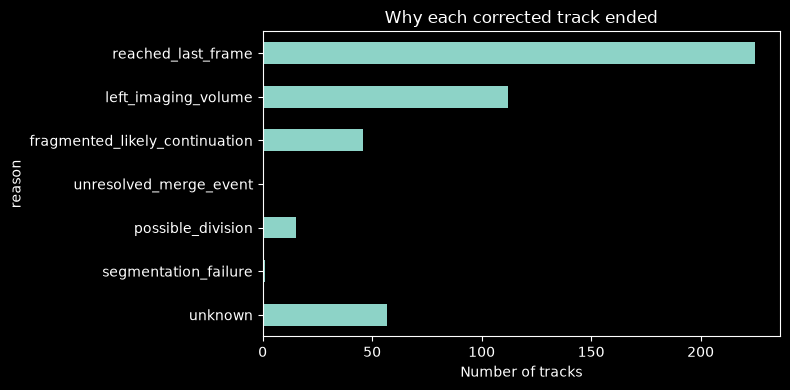

,track_id,last_frame,reason,candidate_track,daughter_a,daughter_b,median_volume,last_volume
0,85,0,left_imaging_volume,NaN,NaN,NaN,NaN,NaN
1,89,0,unknown,NaN,NaN,NaN,NaN,NaN
2,51,0,fragmented_likely_continuation,229.0,NaN,NaN,NaN,NaN
3,47,0,possible_division,NaN,212.0,230.0,NaN,NaN
4,97,0,left_imaging_volume,NaN,NaN,NaN,NaN,NaN
5,139,0,possible_division,NaN,219.0,222.0,NaN,NaN
6,123,0,unknown,NaN,NaN,NaN,NaN,NaN
7,66,1,unknown,NaN,NaN,NaN,NaN,NaN
8,214,1,left_imaging_volume,NaN,NaN,NaN,NaN,NaN
9,217,1,unknown,NaN,NaN,NaN,NaN,NaN


In [15]:
# ------------------------------------------------------------
# Quick visual of the corrected ending breakdown
# ------------------------------------------------------------

plt.figure(figsize=(8, 4))
summary.plot(kind="barh")
plt.xlabel("Number of tracks")
plt.title("Why each corrected track ended")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

track_endings.head(20)


## Save results

`tracks.csv` now contains the merge-corrected trajectories. The detection table remains unchanged because no individual masks or new segmented instances are created. Separate diagnostic files retain every onset, reconstructed center, split link, and track-ID remapping.


In [16]:
output_dir = (
    DATA_ROOT
    / "processed"
    / "stage_8_track_stitching"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True,
)

print("Output directory:", output_dir)


Output directory: D:\Projects\Kaggle\cell-tracking\data\sample\processed\stage_8_track_stitching


In [17]:
# ------------------------------------------------------------
# Save detections and corrected tracks
# ------------------------------------------------------------

detections_df = pd.concat(
    time_frames,
    keys=range(len(time_frames)),
    names=["frame"],
).reset_index(level=0)

detections_df.to_csv(
    output_dir / "detections.csv",
    index=False,
)

tracks.to_csv(
    output_dir / "tracks.csv",
    index=False,
)


# ------------------------------------------------------------
# Save merge diagnostics
# ------------------------------------------------------------

merge_onset_candidates.to_csv(
    output_dir / "merge_onset_candidates.csv",
    index=False,
)

merge_onsets.to_csv(
    output_dir / "merge_onsets.csv",
    index=False,
)

segmentation_events.to_csv(
    output_dir / "segmentation_events.csv",
    index=False,
)

merge_center_trajectories.to_csv(
    output_dir / "merge_center_trajectories.csv",
    index=False,
)

merge_split_links.to_csv(
    output_dir / "merge_split_links.csv",
    index=False,
)

merge_track_repairs.to_csv(
    output_dir / "merge_track_repairs.csv",
    index=False,
)

pd.DataFrame(
    trace_failures
).to_csv(
    output_dir / "merge_trace_failures.csv",
    index=False,
)


# ------------------------------------------------------------
# Save track termination classification
# ------------------------------------------------------------

track_endings.to_csv(
    output_dir / "track_endings.csv",
    index=False,
)


# ------------------------------------------------------------
# Save parameters and execution summary
# ------------------------------------------------------------

metadata = {
    "sample_id": SAMPLE_ID,
    "legacy_gap_closing_enabled": (
        ENABLE_LEGACY_GAP_CLOSING
    ),
    "legacy_max_gap": MAX_GAP,
    "legacy_stitch_max_distance": (
        STITCH_MAX_DISTANCE
    ),
    "merge_detection_enabled": True,
    "merge_detection_signature": (
        "two_tracks_end_then_one_new_track_starts"
    ),
    "voxel_size_zyx": (
        VOXEL_SIZE_ZYX.tolist()
    ),
    "merge_onset_frame_gap": (
        MERGE_ONSET_FRAME_GAP
    ),
    "merge_min_parent_track_length": (
        MERGE_MIN_PARENT_TRACK_LENGTH
    ),
    "merge_exclude_boundary": (
        MERGE_EXCLUDE_BOUNDARY
    ),
    "merge_search_radius_um": (
        MERGE_SEARCH_RADIUS_UM
    ),
    "merge_max_volume_relative_error": (
        MERGE_MAX_VOLUME_REL_ERROR
    ),
    "merge_min_onset_score": (
        MERGE_MIN_ONSET_SCORE
    ),
    "center_alpha_min": CENTER_ALPHA_MIN,
    "center_alpha_max": CENTER_ALPHA_MAX,
    "center_alpha_steps": (
        CENTER_ALPHA_STEPS
    ),
    "center_min_depth_um": (
        CENTER_MIN_DEPTH_UM
    ),
    "merge_max_duration_frames": (
        MERGE_MAX_DURATION_FRAMES
    ),
    "split_min_score": SPLIT_MIN_SCORE,
    "onset_candidate_count": int(
        len(merge_onset_candidates)
    ),
    "accepted_onset_count": int(
        len(merge_onsets)
    ),
    "applied_merge_event_count": int(
        len(segmentation_events)
    ),
    "virtual_center_row_count": int(
        len(merge_center_trajectories)
    ),
    "split_link_count": int(
        len(merge_split_links)
    ),
    "track_remap_count": int(
        len(merge_track_repairs)
    ),
    "trace_failure_count": int(
        len(trace_failures)
    ),
    "track_ids_rewritten": True,
    "individual_masks_created": False,
}

with (
    output_dir / "metadata.json"
).open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        metadata,
        file,
        indent=4,
    )


print(
    f"Saved merge-corrected Stage 8 results to: "
    f"{output_dir}"
)

print("Files:")

for path in sorted(
    output_dir.iterdir()
):
    print(" -", path.name)


Saved merge-corrected Stage 8 results to: D:\Projects\Kaggle\cell-tracking\data\sample\processed\stage_8_track_stitching
Files:
 - detections.csv
 - merge_center_trajectories.csv
 - merge_onset_candidates.csv
 - merge_onsets.csv
 - merge_split_links.csv
 - merge_trace_failures.csv
 - merge_track_repairs.csv
 - metadata.json
 - segmentation_events.csv
 - track_endings.csv
 - tracks.csv
